In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision import transforms
import torch.nn.functional as F
import torch.nn as nn
import torchvision.models as models
import os
import random
from itertools import combinations
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

In [3]:
root_dir = "dataset"

persons = sorted(os.listdir(root_dir)) 
print(len(persons))

40


In [4]:
random.seed(42)
random.shuffle(persons)

In [5]:
train_persons = persons[:30]
test_persons = persons[30:]

print(len(train_persons))
print(len(test_persons))

30
10


In [6]:
def build_dict(persons, root_dir):
    data_dict = {}
    for person in persons:
        person_dir = os.path.join(root_dir, person)
        images = []
        for img_name in sorted(os.listdir(person_dir)):
            img_path = os.path.join(person_dir, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            images.append(img)
        data_dict[person] = images
    return data_dict
train_data = build_dict(train_persons, root_dir)
test_data = build_dict(test_persons, root_dir)

In [7]:
def generate_positive_pairs(data_dict):
    positive_pairs = []
    
    for person, images in data_dict.items():
        for img1, img2 in combinations(images, 2):
            positive_pairs.append((img1, img2, 1))
    
    return positive_pairs

In [8]:
def generate_negative_pairs(data_dict, num_pairs):
    negative_pairs = []
    persons = list(data_dict.keys())
    
    while len(negative_pairs) < num_pairs:
        p1, p2 = random.sample(persons, 2)
        img1 = random.choice(data_dict[p1])
        img2 = random.choice(data_dict[p2])
        negative_pairs.append((img1, img2, 0))
    
    return negative_pairs

In [9]:
train_positive = generate_positive_pairs(train_data)
train_negative = generate_negative_pairs(train_data, len(train_positive))

train_pairs = train_positive + train_negative
random.shuffle(train_pairs)

print("Train pairs:", len(train_pairs))

Train pairs: 2700


In [10]:
test_positive = generate_positive_pairs(test_data)
test_negative = generate_negative_pairs(test_data, len(test_positive))

test_pairs = test_positive + test_negative
random.shuffle(test_pairs)

print("Test pairs:", len(test_pairs))

Test pairs: 900


In [ ]:
class FaceDataset(Dataset):
    def __init__(self, pairs, transform=None):
        self.pairs = pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img1_path, img2_path, label = self.pairs[idx]

        img1 = cv2.imread(img1_path)
        img2 = cv2.imread(img2_path)

        img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
        img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2, torch.tensor(label, dtype=torch.float32)

In [12]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
])

In [13]:
train_dataset = FaceDataset(train_pairs, transform)
img1, img2, label = train_dataset[0]

print(img1.shape)  # должно быть [3, 224, 224]
print(label)       # tensor(0.) или tensor(1.)

torch.Size([3, 224, 224])
tensor(0.)


In [14]:
train_dataset = FaceDataset(train_pairs, transform=transform)
test_dataset  = FaceDataset(test_pairs, transform=transform)

In [15]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

In [16]:
for img1, img2, label in train_loader:
    print(img1.shape)  # должно быть [32, 3, 224, 224]
    print(img2.shape)
    print(label.shape) # [32]
    break

torch.Size([32, 3, 224, 224])
torch.Size([32, 3, 224, 224])
torch.Size([32])


In [17]:
class SiameseNetwork(torch.nn.Module):
    def __init__(self, embedding_dim=128):
        super().__init__()
        
        self.backbone = models.resnet18(pretrained=True)
        self.backbone.fc = nn.Identity()  # удаляем классификационный слой
        
        self.embedding = nn.Linear(512, embedding_dim)
        
    def _forward_once(self, x):
        x = self.backbone(x)
        x = self.embedding(x)
        x = F.normalize(x, p=2, dim=1)  # L2-нормализация
        return x
    
    def forward(self, img1, img2):
        embedding1 = self._forward_once(img1)
        embedding2 = self._forward_once(img2)
        return embedding1, embedding2

def contrastive_loss_cosine(embedding1, embedding2, label, margin=0.5):
    # Косинусная похожесть
    cos_sim = F.cosine_similarity(embedding1, embedding2)
    
    # Косинусное расстояние
    cos_dist = 1 - cos_sim  # 0 = одинаковые, 2 = противоположные
    
    # Contrastive Loss
    loss = 0.5 * (label * cos_dist.pow(2) + (1 - label) * F.relu(margin - cos_dist).pow(2))
    return loss.mean()

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = SiameseNetwork().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
num_epochs = 10

best_loss = float("inf")

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for img1, img2, label in train_loader:
        img1, img2, label = img1.to(device), img2.to(device), label.to(device)

        optimizer.zero_grad()
        emb1, emb2 = model(img1, img2)
        loss = contrastive_loss_cosine(emb1, emb2, label)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    epoch_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

    # 🔥 сохраняем лучшую модель
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(model.state_dict(), "best_model.pth")
        print("Model saved")

c:\conda\envs\osnov\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\conda\envs\osnov\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/10, Loss: 0.0037
Epoch 2/10, Loss: 0.0004
Epoch 3/10, Loss: 0.0002
Epoch 4/10, Loss: 0.0002
Epoch 5/10, Loss: 0.0001
Epoch 6/10, Loss: 0.0001
Epoch 7/10, Loss: 0.0001
Epoch 8/10, Loss: 0.0001
Epoch 9/10, Loss: 0.0001
Epoch 10/10, Loss: 0.0001


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = SiameseNetwork().to(device)
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.eval()

In [ ]:
def evaluate_model(model, loader):
    model.eval()
    all_labels = []
    all_distances = []

    with torch.no_grad():
        for img1, img2, label in loader:
            img1, img2 = img1.to(device), img2.to(device)
            emb1, emb2 = model(img1, img2)

            cos_dist = 1 - F.cosine_similarity(emb1, emb2)
            
            all_distances.extend(cos_dist.cpu().numpy())
            all_labels.extend(label.numpy())

    all_distances = np.array(all_distances)
    all_labels = np.array(all_labels)

    # Подбор лучшего threshold
    thresholds = np.linspace(0, 2, 200)
    best_acc = 0
    best_threshold = 0

    for t in thresholds:
        preds = (all_distances < t).astype(int)
        acc = (preds == all_labels).mean()

        if acc > best_acc:
            best_acc = acc
            best_threshold = t

    print(f"Best threshold: {best_threshold:.3f}")
    print(f"Best accuracy: {best_acc:.4f}")

    return best_threshold, best_acc

best_threshold, best_acc = evaluate_model(model, test_loader)

In [ ]:
def predict_pair(model, img1, img2, transform, threshold, device):
    model.eval()
    with torch.no_grad():
        img1 = transform(img1).unsqueeze(0).to(device)
        img2 = transform(img2).unsqueeze(0).to(device)

        emb1, emb2 = model(img1, img2)
        cos_dist = 1 - F.cosine_similarity(emb1, emb2)

        return "Same person" if cos_dist.item() < threshold else "Different persons"

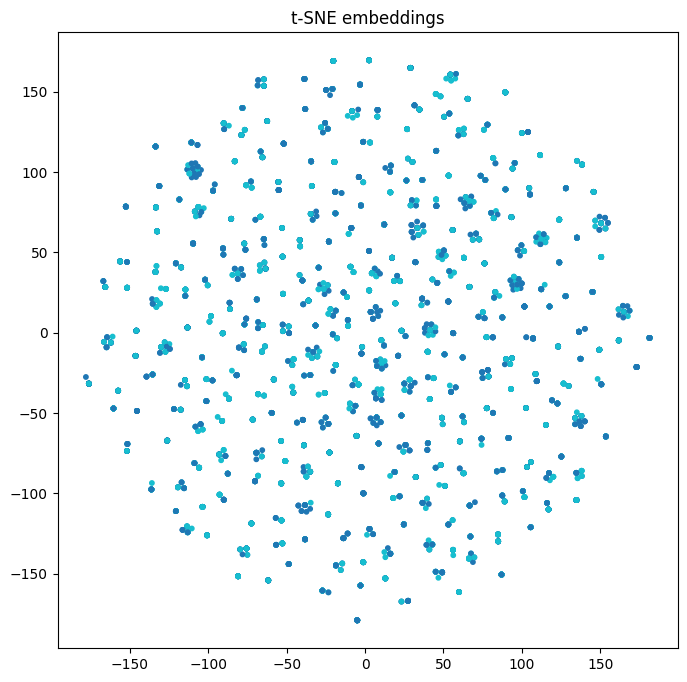

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def visualize_tsne(model, loader, max_samples=1000):
    model.eval()
    embeddings = []
    labels = []
    count = 0

    with torch.no_grad():
        for img1, img2, label in loader:
            img1 = img1.to(device)

            emb = model._forward_once(img1)
            embeddings.append(emb.cpu())
            labels.extend(label.numpy())

            count += len(img1)
            if count > max_samples:
                break

    embeddings = torch.cat(embeddings).numpy()

    tsne = TSNE(n_components=2, random_state=42)
    emb_2d = tsne.fit_transform(embeddings)

    plt.figure(figsize=(8,8))
    plt.scatter(emb_2d[:,0], emb_2d[:,1], s=10)
    plt.title("t-SNE embeddings")
    plt.show()
visualize_tsne(model, test_loader)

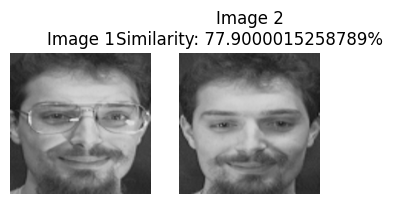

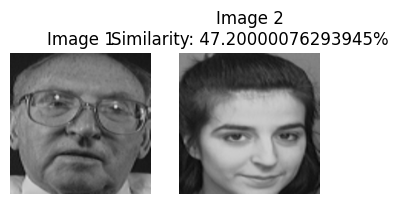

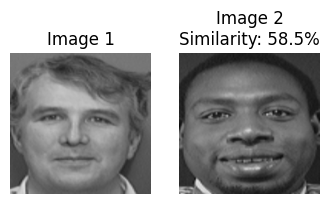

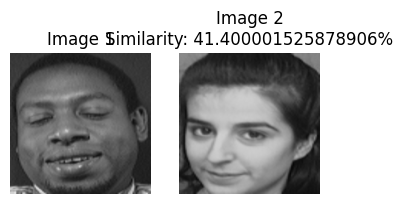

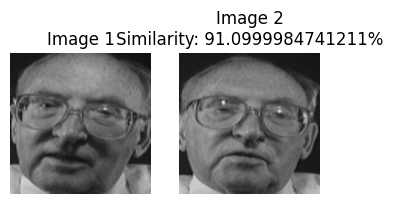

In [ ]:
import random

def show_random_pairs(model, loader, threshold, num_examples=5):
    model.eval()

    with torch.no_grad():
        for img1, img2, label in loader:
            img1, img2 = img1.to(device), img2.to(device)

            emb1, emb2 = model(img1, img2)
            cos_dist = 1 - F.cosine_similarity(emb1, emb2)

            for i in range(len(img1)):
                similarity = 1 - cos_dist[i].item()
                prediction = "Same" if cos_dist[i] < threshold else "Different"

                plt.figure(figsize=(4,2))

                plt.subplot(1,2,1)
                plt.imshow(img1[i].cpu().permute(1,2,0))
                plt.axis("off")

                plt.subplot(1,2,2)
                plt.imshow(img2[i].cpu().permute(1,2,0))
                plt.title(f"{prediction}\nSim: {similarity:.2f}")
                plt.axis("off")

                plt.show()

                num_examples -= 1
                if num_examples == 0:
                    return

show_random_pairs(model, test_loader, best_threshold, num_examples=5)